# Intraday Momentum on SPY – Backtest Notebook

Replication of Zarattini, Aziz & Barbon (2024) and evaluation of our own extensions.

All logic lives in the package `src/intraday_momentum/` and is **only imported here**. The notebook orchestrates, displays and discusses. Reading guide:

| Topic | Document |
|---|---|
| Math of the strategy | [`docs/strategy.md`](../docs/strategy.md) |
| Own extensions (design, hypotheses) | [`docs/extensions.md`](../docs/extensions.md) |
| Report, incl. cross-check with the authors' code | [`docs/report.md`](../docs/report.md) |

**Contents**
1. Setup
2. Data
3. The Noise Area on an example day
4. Paper replication: train vs. test
5. Cost sensitivity
6. Robustness (train period only)
7. Trade-level diagnostics
8. Own strategy (Idea 1: spike filter, Idea 2: meta-labeling)
9. Conclusions

## 1. Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
try:
    import intraday_momentum  # installed via `pip install -e .`
except ModuleNotFoundError:
    sys.path.insert(0, str(ROOT / "src"))  # fallback: import directly from src/

%load_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from intraday_momentum import run_backtest, summarize
from intraday_momentum.evaluation import (COST_SCENARIOS, PAPER_VARIANTS, cost_sensitivity, evaluate, format_table,
                                          load_project_data, make_periods, metric_bar_table, parameter_grid,
                                          summary_view)
from intraday_momentum.diagnostics import false_breakout_stats, pnl_by_entry_time, pnl_by_side, yearly_returns
from intraday_momentum.plotting import (plot_cost_sensitivity, plot_equity_curves, plot_metric_bars,
                                        plot_noise_area_day)

**Parameters.** The split date is fixed *before* looking at any test results. `USE_SYNTHETIC = True` runs the notebook without downloaded data.

In [3]:
SPLIT = "2022-01-01"      # first day of the test period
USE_SYNTHETIC = False     # True -> random-walk data (no API key needed)
SAVE_FIGURES = True       # also write figures to results/

## 2. Data

SPY 1-minute bars (Alpaca SIP, unadjusted, regular session) plus dividends, reshaped into *day × minute* matrices (`data.build_day_data`). The benchmark is SPY buy & hold from adjusted daily closes. If `data/raw` is empty, synthetic data is used automatically.

In [4]:
data, bench = load_project_data(ROOT, synthetic=USE_SYNTHETIC)
if USE_SYNTHETIC or len(data) == 600:
    SPLIT = "2022-06-01"  # synthetic sample is shorter
periods = make_periods(data, SPLIT)
OUT = ROOT / "results" / ("synthetic" if len(data) == 600 else "")
OUT.mkdir(parents=True, exist_ok=True)
save = (lambda name: OUT / name) if SAVE_FIGURES else (lambda name: None)

print(f"{len(data)} trading days: {data.dates[0].date()} -> {data.dates[-1].date()}")
print(f"half days (early close): {(data.n_bars < 390).sum()}")
pd.DataFrame(periods, index=["start", "end"]).T

2703 trading days: 2016-01-04 -> 2026-10-02
half days (early close): 22


,start,end
Train,2016-02-02,2021-12-31
Test,2022-01-01,2026-10-02


## 3. The Noise Area on an example day

Yellow: Noise Area $[\mathrm{LB}_{t,k}, \mathrm{UB}_{t,k}]$. Red dotted line: VWAP. Grey lines: decision times (every 30 minutes). Triangles mark entries and crosses mark exits of the band/VWAP variant.

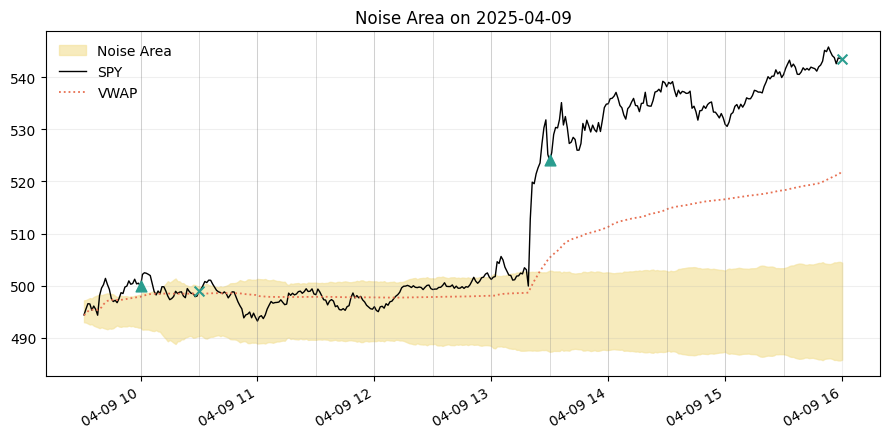

In [5]:
ext1 = run_backtest(data, PAPER_VARIANTS["Ext. 1: + band/VWAP stop"], COST_SCENARIOS["paper"], start=periods["Train"][0])
example_day = str(ext1.returns.idxmax().date())   # best day; try any other date, e.g. "2022-01-20"
plot_noise_area_day(data, example_day, save("noise_area_example.png"), trades=ext1.trades);

## 4. Paper replication: train vs. test

Three variants (base, + band/VWAP stop, + vol targeting) × two cost scenarios × two periods. Each period starts with \$100k. All parameters are the paper's, so **nothing is fitted on the test period**.

In [6]:
summary, full = evaluate(data, PAPER_VARIANTS, COST_SCENARIOS, periods, bench)
summary.to_csv(OUT / "summary.csv", index=False)
format_table(summary_view(summary, "paper"))

,,ann_return,ann_vol,sharpe,max_drawdown,hit_ratio,skew,alpha_ann,beta,trades_per_day
period,strategy,,,,,,,,,
Train,Base: opposite-band stop,2.8%,8.3%,0.37,13.6%,52.2%,0.28,3.6%,-0.03,0.62
Test,Base: opposite-band stop,6.8%,9.5%,0.74,8.9%,55.9%,2.07,6.5%,0.05,0.65
Train,Ext. 1: + band/VWAP stop,4.2%,6.5%,0.66,11.6%,41.8%,0.68,4.6%,-0.02,0.86
Test,Ext. 1: + band/VWAP stop,6.7%,6.6%,1.02,10.0%,45.7%,1.72,6.7%,0.00,0.92
Train,Ext. 2: + vol targeting,13.3%,14.6%,0.93,25.1%,41.8%,2.38,15.2%,-0.09,0.86
Test,Ext. 2: + vol targeting,15.8%,14.2%,1.10,22.3%,45.7%,2.07,16.1%,-0.04,0.92
Train,SPY buy & hold,18.4%,17.5%,1.05,33.8%,56.4%,-0.88,,,
Test,SPY buy & hold,12.2%,17.3%,0.75,24.5%,53.5%,0.34,,,


In [7]:
format_table(summary_view(summary, "conservative"))

,,ann_return,ann_vol,sharpe,max_drawdown,hit_ratio,skew,alpha_ann,beta,trades_per_day
period,strategy,,,,,,,,,
Train,Base: opposite-band stop,2.3%,8.3%,0.32,14.6%,51.4%,0.28,3.1%,-0.03,0.62
Test,Base: opposite-band stop,6.5%,9.5%,0.71,9.0%,55.9%,2.06,6.2%,0.05,0.65
Train,Ext. 1: + band/VWAP stop,3.5%,6.5%,0.56,11.7%,41.3%,0.66,4.0%,-0.02,0.86
Test,Ext. 1: + band/VWAP stop,6.3%,6.6%,0.96,10.2%,45.4%,1.71,6.3%,0.00,0.92
Train,Ext. 2: + vol targeting,11.2%,14.7%,0.80,27.9%,41.3%,2.35,13.3%,-0.09,0.86
Test,Ext. 2: + vol targeting,14.8%,14.2%,1.04,23.1%,45.4%,2.06,15.3%,-0.04,0.92
Train,SPY buy & hold,18.4%,17.5%,1.05,33.8%,56.4%,-0.88,,,
Test,SPY buy & hold,12.2%,17.3%,0.75,24.5%,53.5%,0.34,,,


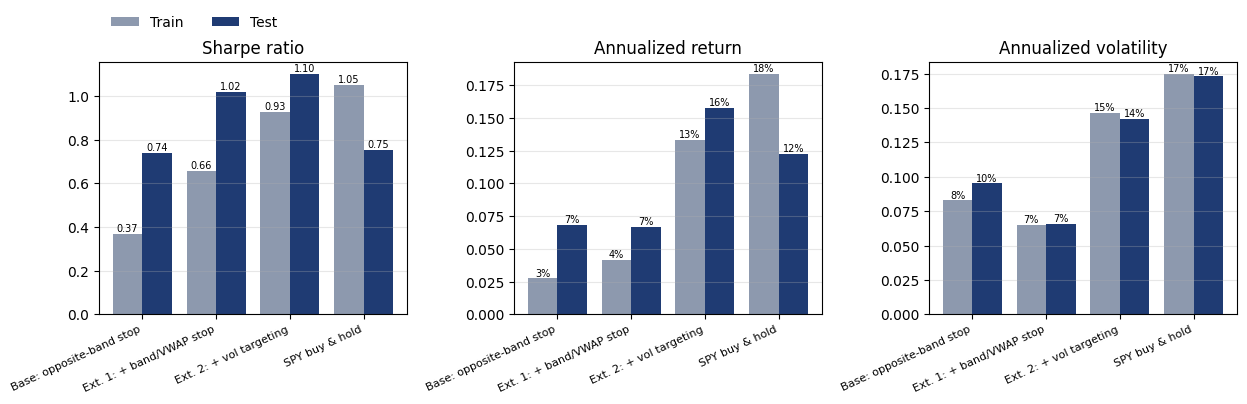

In [8]:
order = list(PAPER_VARIANTS) + ["SPY buy & hold"]
plot_metric_bars(metric_bar_table(summary, "paper", order), save("metrics_train_vs_test.png"));

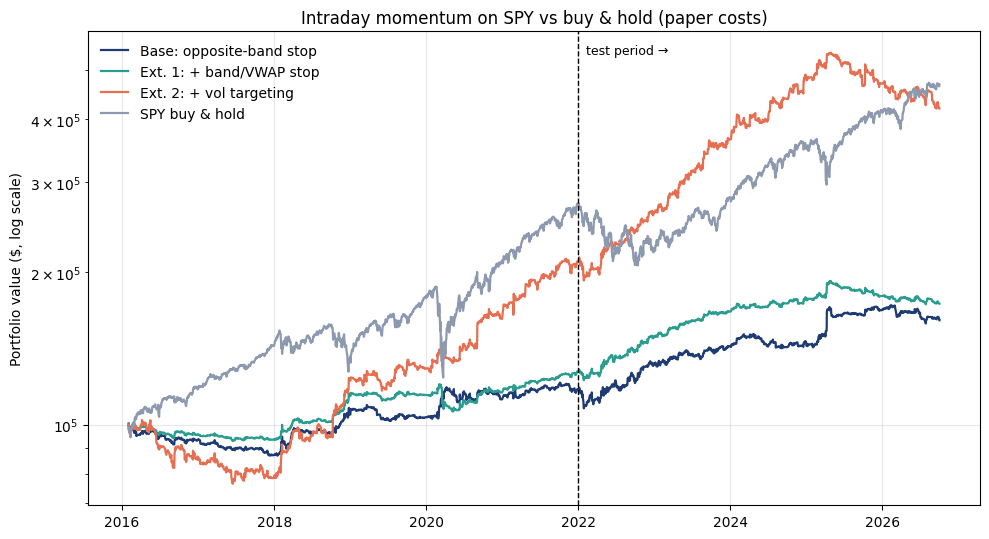

In [9]:
curves = {name: full[("paper", name)].returns for name in PAPER_VARIANTS}
curves["SPY buy & hold"] = bench.loc[periods["Train"][0]:]
plot_equity_curves(curves, SPLIT, save("equity_curves.png"), "Intraday momentum on SPY vs buy & hold (paper costs)");


**Discussion**
- **The paper's ranking holds out of sample.** Base < band/VWAP stop < vol targeting in both periods: test Sharpe 0.74 → 1.02 → 1.10, train 0.37 → 0.66 → 0.93.
- **No drop from train to test.** The test Sharpe is even higher than the train Sharpe. Since all parameters come from the paper, nothing was fitted on our data. The 2022 bear market (high volatility, strong trends) helps the test period.
- **Replication check.** The yearly returns of Ext. 2 match the paper's monthly table with a correlation of 0.99 (2016–2024; see the yearly table in §7). Volatility (≈14%), max drawdown (22–25%) and hit ratio (42–46%) also match.
- **Leverage, not edge.** Ext. 2 roughly doubles the annual return of Ext. 1 (15.8% vs. 6.7% in the test), but the Sharpe only rises from 1.02 to 1.10. The average leverage is ≈2.7x, and the 4x cap binds on ≈22% of days. Compare strategies on Sharpe, not on total return.
- **Market neutral.** Beta ≈ 0 and positive skew in all variants, as in the paper. SPY has the higher Sharpe in the train period (1.05), while the strategies beat SPY on Sharpe in the test period (0.75).


## 5. Cost sensitivity (test period)

Sharpe ratio as a function of total cost per share (commission \$0.0035 + slippage). Where is break-even?

,Base: opposite-band stop,Ext. 1: + band/VWAP stop,Ext. 2: + vol targeting
cost_per_share,,,
0.0035,0.74,1.03,1.12
0.0045,0.74,1.02,1.10
0.0060,0.73,1.00,1.08
0.0085,0.71,0.96,1.04
0.0110,0.69,0.93,1.00
0.0135,0.68,0.89,0.97
0.0185,0.64,0.83,0.89
0.0235,0.61,0.76,0.81


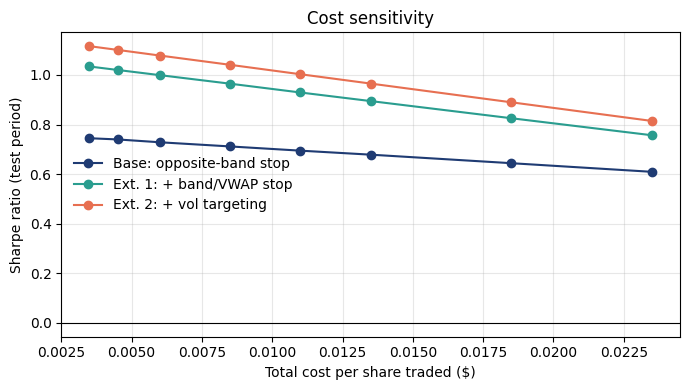

In [10]:
sens = cost_sensitivity(data, PAPER_VARIANTS, periods["Test"])
sens.to_csv(OUT / "cost_sensitivity.csv")
plot_cost_sensitivity(sens, save("cost_sensitivity.png"))
sens.round(2)

**Interpretation.** The edge survives realistic costs. Ext. 1 falls from a Sharpe of about 1.03 at \$0.0035/share to about 0.76 at \$0.0235/share. The average gross profit per round trip is large compared with the costs (≈\$0.12/share in the test period), and break-even lies well above the conservative scenario (\$0.0085/share). Still, every extra cent per share costs roughly 0.13 Sharpe (Ext. 1). Cutting false breakouts would therefore be worth real money.

## 6. Robustness: lookback × volatility multiplier (train period only)

A flat plateau is a good sign, a single sharp peak is a warning sign of overfitting. The **test period is not used here**. The best VM from this grid is also the benchmark for Idea 1 (see `extensions.md` §0.1).

In [11]:
grid = parameter_grid(data, PAPER_VARIANTS["Ext. 2: + vol targeting"], COST_SCENARIOS["paper"], periods["Train"])
grid.to_csv(OUT / "robustness_train_sharpe.csv")
grid.style.format("{:.2f}").background_gradient(cmap="RdYlGn", axis=None)

vol_multiplier,0.800000,1.000000,1.200000,1.500000
lookback_days,,,,
7,0.87,0.89,0.98,0.97
14,0.89,0.93,0.94,1.23
30,1.02,0.84,1.12,0.86
60,0.82,0.83,0.97,0.82


**Interpretation.** The Sharpe ratios range from about 0.8 to 1.2 with no smooth plateau. Parameter choice alone moves the result by ±0.2. That is a reminder of how noisy six years of data are. The best cell (VM = 1.5, lookback 14) matches the paper's own finding in §4.4. We still keep the paper's VM = 1 for the main results, because choosing the best cell would be in-sample optimisation.

## 7. Trade-level diagnostics (train period)

Where does the P&L come from? Only the **training period** is used here, because these analyses motivate our own extensions.

In [12]:
train_s, train_e = periods["Train"]
pnl_by_side(ext1, train_s, train_e).round(3)

,n_trades,hit_ratio,avg_bps,total_gross_pnl
side,,,,
long,681,0.424,2.871,21628.845
short,601,0.326,1.655,10009.258


entry_time,10:00,10:30,11:00,11:30,12:00,12:30,13:00,13:30,14:00,14:30,15:00,15:30
n_trades,361.000,143.000,124.000,87.000,80.00,84.000,59.000,73.000,63.000,75.000,64.000,69.000
hit_ratio,0.399,0.364,0.387,0.322,0.25,0.357,0.322,0.342,0.302,0.413,0.531,0.507
avg_bps,4.167,7.111,4.351,1.786,-7.74,-0.197,-4.906,-5.743,-3.539,8.112,11.586,-0.701


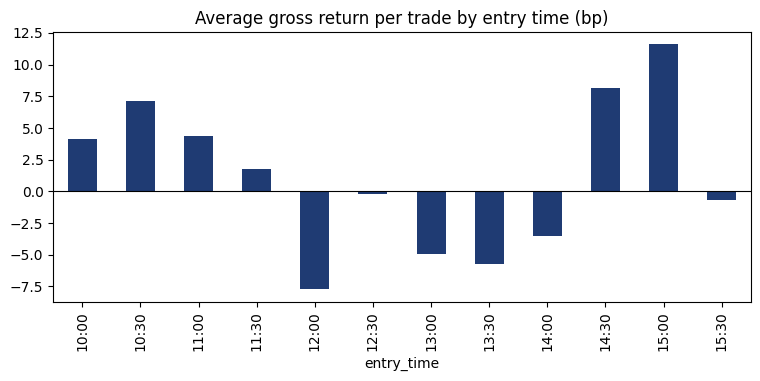

In [13]:
# cf. paper FAQ Q18: do trends pause at lunch time?
by_time = pnl_by_entry_time(ext1, train_s, train_e)
ax = by_time["avg_bps"].plot.bar(figsize=(9, 3.5), color="#1f3b73", title="Average gross return per trade by entry time (bp)")
ax.axhline(0, color="k", lw=0.8);
by_time.round(3).T

In [14]:
# Motivation for Idea 1: how many entries are stopped out again at the very next decision time?
false_breakout_stats(ext1, train_s, train_e).round(3)

n_trades               1282.000
false_breakout_rate       0.342
avg_bps_false           -16.848
avg_bps_other            12.273
dtype: float64

In [15]:
yearly_returns({name: full[("paper", name)].returns for name in PAPER_VARIANTS} | {"SPY": bench.dropna()}).style.format("{:.1%}")

,Base: opposite-band stop,Ext. 1: + band/VWAP stop,Ext. 2: + vol targeting,SPY
date,,,,
2016,-6.5%,-4.3%,-13.4%,13.0%
2017,-6.9%,-2.4%,-9.3%,21.7%
2018,20.3%,21.9%,55.6%,-5.0%
2019,-1.2%,0.5%,5.7%,31.1%
2020,8.4%,1.1%,25.3%,18.5%
2021,4.7%,10.0%,29.7%,28.6%
2022,12.4%,17.2%,25.1%,-18.2%
2023,8.1%,12.1%,39.2%,26.2%
2024,1.6%,6.1%,32.6%,24.9%


**Interpretation (train period, Ext. 1)**
- **False breakouts:** about 34% of entries are stopped out at the very next decision time. They average about −17 bp, compared with about +12.5 bp for all other trades. This is a large, avoidable drag, and the starting point for the extension ideas in `docs/extensions.md`.
- **Time of day:** entries around lunch (12:00–14:00) have a negative average return. Morning entries and entries after 14:30 are positive. This is consistent with the paper's FAQ Q18.
- **Long vs. short:** both sides contribute positively; the long side contributes more (positive drift of SPY).
- **Yearly returns:** weak in calm years (2016–17) and strong in trending, volatile years (2018, 2022). Since 2025 the returns have been flat to negative.

## 8. Own strategy: ML long/short/flat model

Design and reasoning: [`docs/extensions.md`](../docs/extensions.md). In short:

- **Same decision grid as the paper** (every 30 min from 10:00, flat at the close) and the same execution, costs and sizing. Only the *decision rule* changes.
- **Model:** logistic regression (L2, standardised features) for $P(\text{return from now to the close} > 0)$.
- **Position:** $+1$ if $p > 0.5 + m$, $-1$ if $p < 0.5 - m$, else flat. Re-evaluated every 30 minutes, so a model turning neutral acts as the stop.
- **Features:** 7 features inspired by the paper, all known at the decision time (unit-tested for look-ahead).
- **Selection:** feature set, $C$ and margin $m$ are chosen by expanding-window CV by year **on the training period only** (validation years 2018–2021). Then one final fit on 2016–2021 and one evaluation on the test period.

In [16]:
from intraday_momentum.features import FEATURE_DESCRIPTIONS
from intraday_momentum.ml_strategy import ML_VARIANTS, ml_pipeline
from intraday_momentum.evaluation import SUBPERIODS, subperiod_table

pd.Series(FEATURE_DESCRIPTIONS, name="definition").to_frame()

,definition
move_sigma,move from the open in units of the Noise-Area ...
vwap_sigma,distance to VWAP in sigma units: (P/VWAP - 1) ...
gap_z,overnight gap (dividend-adjusted) / trailing 1...
ret30_z,return over the last 30 minutes / trailing 14-...
time_of_day,minutes since the open / 390
rsi5,"5-day RSI of SPY at the previous close, rescal..."
vol_regime,log(5-day vol / 60-day vol) of daily returns (...
paper_signal,"+1 if P > max(UB, VWAP), -1 if P < min(LB, VWA..."


In [17]:
ml_run = ml_pipeline(data, periods, COST_SCENARIOS, bench)   # CV + final fit + evaluation (~10 s)
print("Selected:", ml_run.cfg)
ml_run.feature_set_comparison.round(3)

Selected: MLConfig(C=0.01, margin=0.02, features=('move_sigma', 'vwap_sigma', 'gap_z', 'ret30_z', 'time_of_day', 'rsi5', 'vol_regime'))


,mean_sharpe,min_sharpe,mean_auc,trades_per_day
"A: 7 features (best C=0.01, margin=0.02)",0.530,-0.278,0.532,1.033
"B: A + paper signal (best C=1.0, margin=0.01)",0.354,-0.221,0.529,1.313


**Cross-validation on the training period** (mean over the validation years 2018–2021). The margin controls how often the model trades and therefore the costs.

In [18]:
ml_run.cv_table.round(3)

,,mean_sharpe,min_sharpe,mean_auc,trades_per_day
C,margin,,,,
0.01,0.02,0.530,-0.278,0.532,1.033
0.10,0.02,0.525,-0.181,0.532,1.036
1.00,0.02,0.512,-0.209,0.532,1.040
0.10,0.00,0.420,-0.484,0.532,1.299
1.00,0.00,0.405,-0.451,0.532,1.298
0.01,0.00,0.338,-0.410,0.532,1.280
1.00,0.01,0.316,-0.187,0.532,1.174
0.10,0.01,0.291,-0.195,0.532,1.174
0.01,0.01,0.268,-0.325,0.532,1.163


In [19]:
# Per validation year for the selected parameters: is the result stable over time?
sel = ml_run.cv[(ml_run.cv.C == ml_run.cfg.C) & (ml_run.cv.margin == ml_run.cfg.margin)]
sel.set_index("year")[["sharpe", "ann_return", "auc", "trades_per_day"]].round(3)

,sharpe,ann_return,auc,trades_per_day
year,,,,
2018,1.114,0.135,0.503,0.916
2019,0.231,0.013,0.516,1.056
2020,-0.278,-0.065,0.536,1.004
2021,1.051,0.077,0.573,1.155


**What did the model learn?** Coefficients on standardised features (sign = direction of the effect on $P(\text{up})$). AUC 0.5 = no skill.

,coef
vol_regime,-0.148
vwap_sigma,0.079
time_of_day,-0.059
move_sigma,-0.058
rsi5,0.031
gap_z,-0.015
ret30_z,0.001


,AUC
train (in-sample),0.554
test,0.518


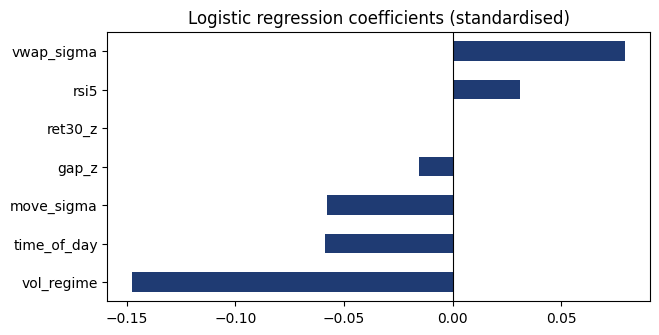

In [20]:
ax = ml_run.coefficients.sort_values().plot.barh(figsize=(7, 3.5), color="#1f3b73", title="Logistic regression coefficients (standardised)")
ax.axvline(0, color="k", lw=0.8)
display(ml_run.coefficients.round(3).to_frame("coef"))
ml_run.auc.round(3).to_frame("AUC")

### 8.1 Comparison with the paper rule (same split, costs and metrics)

In [21]:
paper_sel = {k: PAPER_VARIANTS[k] for k in ["Ext. 1: + band/VWAP stop", "Ext. 2: + vol targeting"]}
cmp_summary = pd.concat([summary[summary.strategy.isin(list(paper_sel) + ["SPY buy & hold"])], ml_run.summary],
                        ignore_index=True)
format_table(summary_view(cmp_summary, "paper"))

,,ann_return,ann_vol,sharpe,max_drawdown,hit_ratio,skew,alpha_ann,beta,trades_per_day
period,strategy,,,,,,,,,
Train,Ext. 1: + band/VWAP stop,4.2%,6.5%,0.66,11.6%,41.8%,0.68,4.6%,-0.02,0.86
Test,Ext. 1: + band/VWAP stop,6.7%,6.6%,1.02,10.0%,45.7%,1.72,6.7%,0.00,0.92
Train,Ext. 2: + vol targeting,13.3%,14.6%,0.93,25.1%,41.8%,2.38,15.2%,-0.09,0.86
Test,Ext. 2: + vol targeting,15.8%,14.2%,1.10,22.3%,45.7%,2.07,16.1%,-0.04,0.92
Train,SPY buy & hold,18.4%,17.5%,1.05,33.8%,56.4%,-0.88,,,
Test,SPY buy & hold,12.2%,17.3%,0.75,24.5%,53.5%,0.34,,,
Train,ML: logistic (1x),-0.3%,9.6%,0.02,23.6%,52.0%,-1.01,1.6%,-0.08,1.21
Test,ML: logistic (1x),5.7%,10.3%,0.59,12.8%,51.3%,-1.35,6.5%,-0.03,1.32
Train,ML: logistic + vol targeting,3.9%,20.6%,0.29,33.1%,52.0%,-0.22,3.8%,0.12,1.21


In [22]:
format_table(summary_view(cmp_summary, "conservative"))

,,ann_return,ann_vol,sharpe,max_drawdown,hit_ratio,skew,alpha_ann,beta,trades_per_day
period,strategy,,,,,,,,,
Train,Ext. 1: + band/VWAP stop,3.5%,6.5%,0.56,11.7%,41.3%,0.66,4.0%,-0.02,0.86
Test,Ext. 1: + band/VWAP stop,6.3%,6.6%,0.96,10.2%,45.4%,1.71,6.3%,0.00,0.92
Train,Ext. 2: + vol targeting,11.2%,14.7%,0.80,27.9%,41.3%,2.35,13.3%,-0.09,0.86
Test,Ext. 2: + vol targeting,14.8%,14.2%,1.04,23.1%,45.4%,2.06,15.3%,-0.04,0.92
Train,SPY buy & hold,18.4%,17.5%,1.05,33.8%,56.4%,-0.88,,,
Test,SPY buy & hold,12.2%,17.3%,0.75,24.5%,53.5%,0.34,,,
Train,ML: logistic (1x),-1.1%,9.6%,-0.07,24.6%,51.6%,-1.01,0.7%,-0.08,1.21
Test,ML: logistic (1x),5.1%,10.3%,0.54,13.0%,51.1%,-1.35,5.9%,-0.03,1.32
Train,ML: logistic + vol targeting,1.3%,20.6%,0.17,34.7%,51.6%,-0.22,1.3%,0.12,1.21


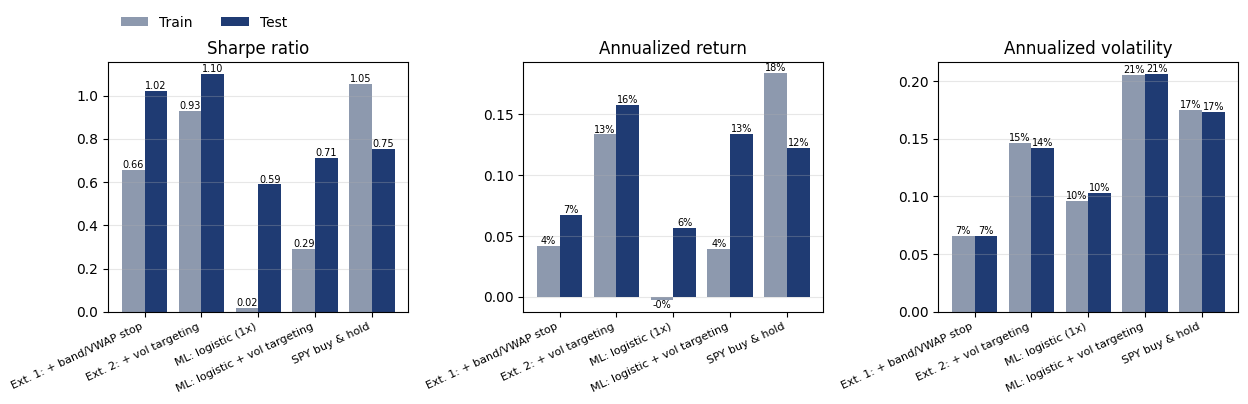

In [23]:
ml_order = list(paper_sel) + list(ML_VARIANTS) + ["SPY buy & hold"]
plot_metric_bars(metric_bar_table(cmp_summary, "paper", ml_order), save("ml_metrics_train_vs_test.png"));

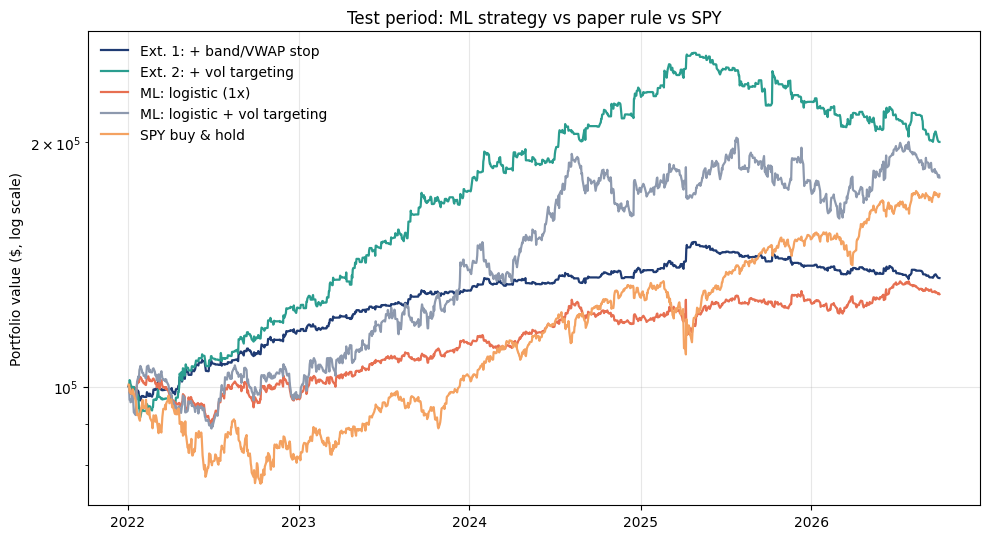

In [24]:
test_start = periods["Test"][0]
all_res = {**full, **ml_run.full}
ml_curves = {n: all_res[("paper", n)].returns.loc[test_start:] for n in ml_order[:-1]}
ml_curves["SPY buy & hold"] = bench.loc[test_start:]
plot_equity_curves(ml_curves, None, save("ml_equity_test.png"), "Test period: ML strategy vs paper rule vs SPY");

### 8.2 Before vs. after the paper's publication (May 2024), and diversification

In [25]:
sub_returns = {"Ext. 1: + band/VWAP stop": full[("paper", "Ext. 1: + band/VWAP stop")].returns,
               "ML: logistic (1x)": ml_run.full[("paper", "ML: logistic (1x)")].returns}
display(format_table(subperiod_table(sub_returns, SUBPERIODS, bench)))
corr = pd.concat(sub_returns, axis=1).loc[test_start:].corr().iloc[0, 1]
print(f"Correlation of daily returns, ML vs Ext. 1 (test period): {corr:.2f}")

ann_return ann_vol sharpe max_drawdown sharpe_t
period                                       strategy                                                                
Test, before publication (2022-01 - 2024-04) Ext. 1: + band/VWAP stop      14.2%    7.3%   1.86         4.7%     2.83
                                             ML: logistic (1x)              6.6%   10.3%   0.67        12.8%     1.02
                                             SPY buy & hold                 3.9%   18.6%   0.30        24.5%     0.46
After publication (2024-05 - today)          Ext. 1: + band/VWAP stop       0.0%    5.8%   0.03        10.0%     0.05
                                             ML: logistic (1x)              4.8%   10.3%   0.51         9.4%     0.79
                                             SPY buy & hold                20.8%   16.0%   1.26        18.8%     1.96

Correlation of daily returns, ML vs Ext. 1 (test period): -0.03



**Discussion**
- **Selection.** CV on 2018–2021 picks feature set A (7 features), C = 0.01 (the strongest regularisation) and margin 0.02. Adding the paper's discrete signal (set B) *lowers* the validation Sharpe (0.35 vs. 0.53), because the continuous features already contain that information. The validation results vary a lot by year (Sharpe −0.28 to 1.11), which is typical for a weak signal.
- **Is the edge real? Small but yes.** The test AUC is 0.518 (in-sample 0.554). That is above 0.5 but modest. With about 1,200 test *days* (the 12 rows per day are strongly dependent), this is a small effect.
- **What the model learned.**
  - Rising volatility lowers the odds of an up-move into the close: $e^{-0.148} \approx 0.86$, i.e. about −14% per standard deviation.
  - Trading above VWAP raises them. This supports the paper's VWAP logic.
  - Later in the day the odds fall, because less time remains for the positive drift.
  - Given the VWAP distance, an extended move from the open fades slightly. The two features are correlated, so only their combination should be interpreted.
- **H2 rejected: ML does not beat the rule.** Test Sharpe 0.59 vs. 1.02 (1x) and 0.71 vs. 1.10 (vol targeting), with the same ranking under conservative costs. The reason lies in the payoff profile. The rule cuts losers and lets winners run (skew +1.7). The model trades on small probability differences, with a hit ratio of about 51% and skew of −1.35.
- **Not overfitted.** The in-sample train Sharpe is about 0.02 and the test Sharpe is 0.59. An overfitted model would show the opposite.
- **Where it helps.** After the paper's publication, ML keeps a Sharpe of 0.51 while the rule drops to about 0.03. The two return streams are uncorrelated (ρ ≈ −0.03). An inverse-volatility mix would have reached a test Sharpe of about 1.15. This is descriptive only, because the weights were not chosen on the training period.



## 9. Conclusions

1. **Replication.** Our independent Python implementation reproduces the paper closely: the yearly returns of the full model correlate 0.99 with the paper's table, and volatility, drawdown, hit ratio and beta also match. A cross-check with the authors' reference code found two details we had missed at first (dividend adjustment, minimum commission). It also showed that the reference code applies no slippage.
2. **Out of sample.** With the paper's parameters (nothing fitted on our data), the strategy keeps its edge in 2022–2026: Ext. 1 Sharpe 1.02 and Ext. 2 Sharpe 1.10 vs. 0.75 for SPY. Beta is about 0 and skew positive. Most of the extra return from vol targeting is leverage.
3. **Costs.** The results hold under conservative costs (Sharpe −0.05 to −0.13), and break-even is far above realistic cost levels for SPY.
4. **Caveat: after publication.** From May 2024 on, all paper variants have a Sharpe of about 0. With 2.4 years of data we cannot distinguish alpha decay from a calm-market regime (t ≈ 0.2).
5. **Own strategy.** A simple, strongly regularised logistic regression on paper-inspired features has a small but real out-of-sample edge (AUC 0.518). It does **not** beat the rule over the full test period (Sharpe 0.59 vs. 1.02). It did hold up better after publication, and it is uncorrelated with the rule.
6. **Further improvements.**
   - Combine rule and ML, with weights chosen on the training period.
   - Remove the drift from the label, and size positions by confidence instead of ±1.
   - Try shallow nonlinear models with the same CV protocol.
   - Add VIX, FOMC and range-compression features.
   - Re-fit walk-forward every year.
   - Go multi-asset (QQQ, IWM, …) for more independent bets.

*"Roughly right rather than precisely wrong":* the main value of this study is an honest, look-ahead-free test. It confirms the paper in-sample and out of sample until 2024, and it shows where the edge is weakening.
